In [1]:
import nltk
from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
import pandas as pd

from core.plot_utils import plot_2d

nltk.download('stopwords')
russian_stopwords = stopwords.words("russian")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def find_optimal_k(X, K: range = range(2, 200), plot_results=True):
    K = list(K)
    inertias = []
    silhouettes = []

    for k in K:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)
        score = silhouette_score(X, labels)
        silhouettes.append(score)
        print(f"k={k}: inertia={model.inertia_:.0f}, silhouette={score:.3f}")

    # Визуализация
    if plot_results:
        plot_2d(list(K), inertias, "Количество кластеров (k)", "Inertia", "Метод локтя")
        plot_2d(list(K), silhouettes, "Количество кластеров (k)", "Silhouette Score", "Silhouette")

    best_silhouette = max((s for s in silhouettes if not pd.isna(s)), default=None)
    best_k = K[silhouettes.index(best_silhouette)] if best_silhouette is not None else None
    best_inertia = inertias[K.index(best_k)] if best_k is not None else None
    return {
        "best_k": best_k,
        "best_silhouette": best_silhouette,
        "best_inertia": best_inertia,
        "inertias": inertias,
        "silhouettes": silhouettes,
        "k_values": K,
    }


def test_tfidf_configs(texts, vectorizer_params_list, K=range(2, 50)):
    """
    Перебирает разные конфигурации TfidfVectorizer,
    вызывает find_optimal_k() для каждой и рисует
    два итоговых графика: Inertia и Silhouette Score.
    """
    all_results = []

    for params in vectorizer_params_list:
        print(f"\n🔹 TF-IDF параметры: {params}")

        # 1️⃣ Векторизация текста
        vectorizer = TfidfVectorizer(**params)
        X = vectorizer.fit_transform(texts)

        # 2️⃣ Используем твою функцию find_optimal_k
        res = find_optimal_k(X, K, plot_results=False)
        all_results.append({
            "params": params,
            "inertias": res["inertias"],
            "silhouettes": res["silhouettes"],
            "k_values": list(res["k_values"]),
            "best_k": res["best_k"],
            "best_silhouette": res["best_silhouette"]
        })

    # 3️⃣ Общие графики сравнения
    plt.figure(figsize=(12, 5))

    # --- Inertia ---
    plt.subplot(1, 2, 1)
    for r in all_results:
        plt.plot(r["k_values"], r["inertias"], marker='o', label=str(r["params"]))
    plt.title("Inertia для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Inertia")
    plt.legend()
    plt.grid(True)

    # --- Silhouette ---
    plt.subplot(1, 2, 2)
    for r in all_results:
        plt.plot(r["k_values"], r["silhouettes"], marker='o', label=str(r["params"]))
    plt.title("Silhouette Score для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Silhouette Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return all_results


In [3]:
df = pd.read_csv('../../../data/events/2_struct/2000-2025.csv')

# Пробуем первую попавшуюся модель кластеризации
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

k = 186
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - состоялись акции протеста во многих городах России против платного основного образования.

🟢 Кластер 1
  - Партия «Ликуд» во главе с Ариэлем Шароном выиграла парламентские выборы в Израиле.
  - парламентские выборы в Израиле. Большинство (31) голосов получил предвыборный блок партий Ликуд и Наш дом — Израиль во главе с действующим премьер-министром Биньямином Нетаньяху.
  - досрочные парламентские выборы в Израиле. Победу одержала правящая партия Ликуд.
  - на парламентских выборах в Израиле победу одержала партия Ликуд во главе с бывшим премьер-министром страны Биньямином Нетаньяху.

🟢 Кластер 2
  - на Гренаде прошли парламентские выборы на которых были избраны 15 депутатов Палаты представителей. Новая национальная партия (ННП) получила меньшее число мест, чем на предыдущих выборах, но тем не менее обеспечила себе большинство в парламенте. Лидер ННП Кит Митчелл в 3-й раз стал премьер-министром страны. Участие составило 57,7 %.

🟢 Кластер 3
  - На Филиппинах в результа

In [4]:
# Находим оптимальное число кластеров у первой попавшейся модели
find_optimal_k(X, range(2, 200))
# По графику делаю вывод, что с увеличением кол-ва кластеров результаты постепенно улучшаются. Локоть не наблюдается.
# Время выполнения: ~9m минут. Лучший результат: k=199: inertia=4495, silhouette=0.042

k=2: inertia=5541, silhouette=0.007
k=3: inertia=5504, silhouette=0.010
k=4: inertia=5470, silhouette=0.011
k=5: inertia=5437, silhouette=0.013
k=6: inertia=5419, silhouette=0.014
k=7: inertia=5392, silhouette=0.016
k=8: inertia=5372, silhouette=0.014
k=9: inertia=5341, silhouette=0.016
k=10: inertia=5322, silhouette=0.018
k=11: inertia=5307, silhouette=0.016
k=12: inertia=5293, silhouette=0.018
k=13: inertia=5290, silhouette=0.017
k=14: inertia=5282, silhouette=0.016
k=15: inertia=5259, silhouette=0.019
k=16: inertia=5259, silhouette=0.019
k=17: inertia=5250, silhouette=0.018
k=18: inertia=5233, silhouette=0.020
k=19: inertia=5227, silhouette=0.020
k=20: inertia=5223, silhouette=0.019
k=21: inertia=5201, silhouette=0.021
k=22: inertia=5194, silhouette=0.021
k=23: inertia=5186, silhouette=0.020
k=24: inertia=5174, silhouette=0.023
k=25: inertia=5179, silhouette=0.022
k=26: inertia=5163, silhouette=0.021
k=27: inertia=5151, silhouette=0.020
k=28: inertia=5152, silhouette=0.020
k=29: ine

{'best_k': 183,
 'best_silhouette': 0.042233084498949795,
 'best_inertia': 4524.8509707261965,
 'inertias': [5540.939372552054,
  5503.804030368206,
  5469.743503149172,
  5437.425800103063,
  5419.272888158018,
  5391.917446020909,
  5372.002533932478,
  5341.233642207571,
  5321.900229181019,
  5307.474582805107,
  5293.494679408495,
  5290.111910530361,
  5282.008940806943,
  5259.382015833464,
  5258.94242539527,
  5249.91269130094,
  5232.86269461293,
  5227.321021692365,
  5223.370798155675,
  5200.8179208764805,
  5193.678020075782,
  5186.454801758258,
  5173.815101784787,
  5179.379040092433,
  5162.59947688414,
  5151.145097991773,
  5151.566608735172,
  5136.497495906782,
  5118.958491670206,
  5120.910994909166,
  5119.233897120005,
  5112.544959326484,
  5090.084346753236,
  5102.94288077206,
  5086.5074776284055,
  5087.790951159221,
  5077.549738084847,
  5064.733647115647,
  5066.528175929311,
  5048.877755825066,
  5047.053463202006,
  5047.432616498966,
  5036.2268112


🔹 TF-IDF параметры: {'max_features': 1000}
k=2: inertia=5397, silhouette=0.016
k=3: inertia=5336, silhouette=0.019
k=4: inertia=5275, silhouette=0.022
k=5: inertia=5239, silhouette=0.023
k=6: inertia=5207, silhouette=0.025
k=7: inertia=5168, silhouette=0.027
k=8: inertia=5103, silhouette=0.030
k=9: inertia=5067, silhouette=0.034
k=10: inertia=5059, silhouette=0.035
k=11: inertia=5007, silhouette=0.036
k=12: inertia=5002, silhouette=0.037
k=13: inertia=4980, silhouette=0.038
k=14: inertia=4948, silhouette=0.038
k=15: inertia=4943, silhouette=0.037
k=16: inertia=4932, silhouette=0.041
k=17: inertia=4916, silhouette=0.037
k=18: inertia=4881, silhouette=0.040
k=19: inertia=4867, silhouette=0.040
k=20: inertia=4891, silhouette=0.039
k=21: inertia=4826, silhouette=0.043
k=22: inertia=4824, silhouette=0.041
k=23: inertia=4816, silhouette=0.042
k=24: inertia=4795, silhouette=0.041
k=25: inertia=4782, silhouette=0.045
k=26: inertia=4755, silhouette=0.046
k=27: inertia=4741, silhouette=0.047
k=

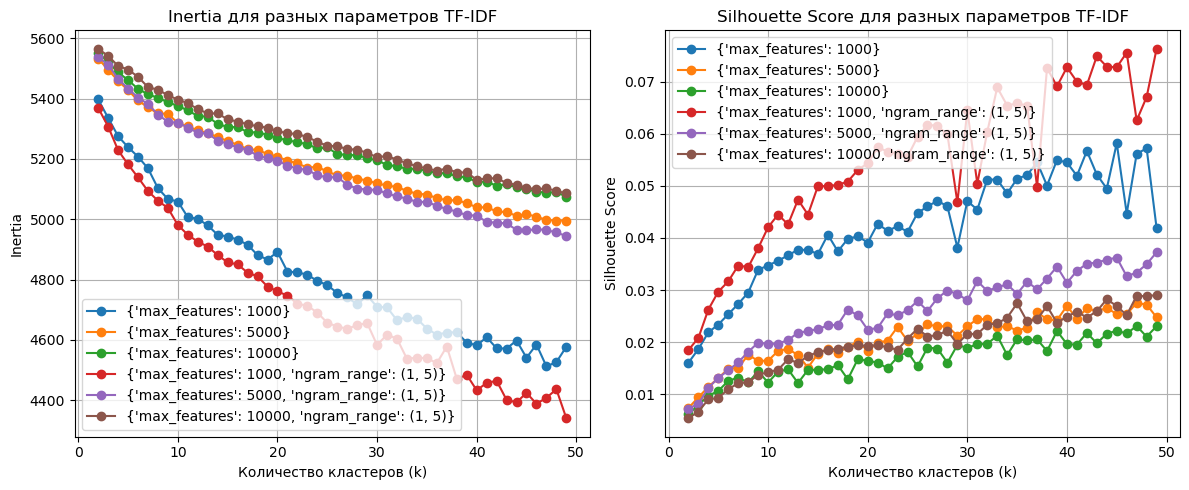

[{'params': {'max_features': 1000},
  'inertias': [5396.7840644062335,
   5335.71328940833,
   5275.20468025421,
   5238.6160553843,
   5207.267758762104,
   5168.470482181517,
   5102.679275251774,
   5066.784719994003,
   5058.572302351466,
   5006.571466165522,
   5001.79824952975,
   4979.5182443955855,
   4948.1938370281405,
   4942.667660877158,
   4932.343436224537,
   4915.612385128596,
   4881.089467733276,
   4866.530527297048,
   4891.35545675996,
   4826.4763868565915,
   4823.987156966041,
   4816.369981972935,
   4795.220936515985,
   4782.136351472735,
   4755.428991301217,
   4741.427307668874,
   4717.545538880031,
   4747.308599956742,
   4709.615651546395,
   4707.93359871902,
   4665.177578769561,
   4676.214747816475,
   4670.310610641511,
   4637.594089022273,
   4617.342854233066,
   4624.624886381492,
   4625.364593469675,
   4591.210520860616,
   4581.87338815552,
   4608.953509530056,
   4572.194696539117,
   4571.565551436112,
   4597.977022377566,
   4540.93

In [5]:
# Пытаемся определить лучший векторизатор текста путем перебора различных параметров
configs = [
    {"max_features": 1000}, # вариант, хуже дефолтного
    {"max_features": 5000}, # дефолтный вариант
    {"max_features": 10_000}, # улучшенный дефолтный вариант
    {"max_features": 1000, "ngram_range": (1, 5)},
    {"max_features": 5000, "ngram_range": (1, 5)},
    {"max_features": 10000, "ngram_range": (1, 5)},
]

df["clean_event"] = df["event"].str.lower()
results = test_tfidf_configs(df["clean_event"], configs, K=range(2, 50))
results
# Лучший результат показали n_features=1000 с n-граммами (k=48: inertia=4373, silhouette=0.077). Попробуем найти для него подходящее кол-во кластеров
# время выполнения 5m

In [6]:
# мы определили лучший векторизатор, теперь пробуем найти подходящее кол-во кластеров
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 5),
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

find_optimal_k(X, range(2, 200))
# best k=190: inertia=3389, silhouette=0.125. Время выполнения 6m 28s

k=2: inertia=5341, silhouette=0.020
k=3: inertia=5277, silhouette=0.024
k=4: inertia=5229, silhouette=0.026
k=5: inertia=5168, silhouette=0.031
k=6: inertia=5132, silhouette=0.034
k=7: inertia=5084, silhouette=0.036
k=8: inertia=5057, silhouette=0.038
k=9: inertia=5002, silhouette=0.041
k=10: inertia=4972, silhouette=0.043
k=11: inertia=4970, silhouette=0.043
k=12: inertia=4984, silhouette=0.037
k=13: inertia=4915, silhouette=0.043
k=14: inertia=4883, silhouette=0.046
k=15: inertia=4855, silhouette=0.049
k=16: inertia=4830, silhouette=0.053
k=17: inertia=4834, silhouette=0.050
k=18: inertia=4782, silhouette=0.054
k=19: inertia=4768, silhouette=0.053
k=20: inertia=4779, silhouette=0.054
k=21: inertia=4778, silhouette=0.051
k=22: inertia=4710, silhouette=0.059
k=23: inertia=4696, silhouette=0.059
k=24: inertia=4705, silhouette=0.056
k=25: inertia=4714, silhouette=0.052
k=26: inertia=4664, silhouette=0.059
k=27: inertia=4655, silhouette=0.060
k=28: inertia=4667, silhouette=0.052
k=29: ine

{'best_k': 199,
 'best_silhouette': 0.12260147514783966,
 'best_inertia': 3364.110667607556,
 'inertias': [5341.451082222802,
  5276.868625975997,
  5229.49638816734,
  5167.819297722328,
  5131.555444459771,
  5083.7314674437175,
  5056.815588824826,
  5001.860169375517,
  4972.229947222688,
  4970.062229899661,
  4984.495631083921,
  4915.1811238791015,
  4883.153404490896,
  4855.417203261671,
  4830.085542221401,
  4833.952939755778,
  4782.277820328869,
  4768.104907528173,
  4779.091530338578,
  4777.696910461436,
  4710.115918219084,
  4695.913571526877,
  4705.305186745343,
  4714.023887756889,
  4663.966497738316,
  4655.384468551449,
  4667.078356313456,
  4614.4404507607405,
  4620.256870046665,
  4589.346569302711,
  4612.558873441042,
  4538.249512380311,
  4534.9656163905365,
  4544.774650491667,
  4584.758245003573,
  4508.209519253728,
  4536.246816236241,
  4453.663463560783,
  4445.203056712961,
  4494.828338678482,
  4440.01564799747,
  4456.816210402711,
  4457.5514

In [7]:
# пробуем лучшую модель в действии
k = 190
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - начался второй этап акции «Украина без Кучмы», который длился до 1 марта. Всё это время на Крещатике и Майдане Независимости проводились массовые акции протеста, митинги и манифестации. 1 марта палаточный городок на Крещатике был ликвидирован силовыми подразделениями.
  - В иерусалимской гостинице «Хаят» боевиками НФОП застрелен министр туризма Израиля Рехаваам Зеэви. В этот день он был намерен покинуть коалицию Шарона в знак протеста против частичного вывода войск из Хеврона.
  - Погиб ливанский политический деятель Рафик Харири, начало массовых акций протеста за вывод сирийских войск с территории Ливана. По аналогии с цветными революциями на постсоветском пространстве акции получили название «революция кедров» (или «кедровая революция»).
  - китайские солдаты оружием подавили акцию протеста уйгуров в г. Урумчи, были убитые и раненые.
  - в Калининграде состоялся крупнейший в России с 1990-х годов митинг протеста против действия властей.
  - состоялись акции протеста 